In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import numpy as np

df = pd.read_csv("/content/drive/MyDrive/final_project/cleaned_book_data.csv")

df['genres_list'] = df['genres_list'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else np.nan)
df.head()

,title,series_title,series_release_number,authors,publisher,publication_date,language,description,number_of_pages,format,...,current_readers,want_to_read,comment_1,comment_2,comment_3,comment_4,publication_year,publication_month,publication_day,genres_list
0,Felicity Saves the Day: A Summer Story,American Girl: Felicity,5,Valerie Tripp,American Girl,1992-07-01,English,Felicity loves summertime on Grand father's pl...,88,Paperback,...,38.0,793.0,"It was so great to have Penny come back, and F...","""You are a coward. It's cowardly to break prom...","Ahhh, summertime on a Virginia plantation. So ...",yay penny! love a girl and her animal having a...,1992.0,7.0,1.0,"[Historical Fiction, Childrens, Fiction, Histo..."
1,The Lake of Darkness,Standalone,NaN,Ruth Rendell,Vintage Crime/Black Lizard,2001-09-01,English,Martin Urban is a quiet bachelor with a comfor...,210,Paperback,...,89.0,667.0,No Good Deed Goes UnpunishedReview of the Arro...,Ruth Rendell is on fine form in this short nov...,I was a bit disappointed by Master of the Moor...,"Martin, an ordinary, middle-class accountant w...",2001.0,9.0,1.0,"[Mystery, Fiction, Crime, Thriller, British Li..."
2,Beyond the Blue Event Horizon,Heechee Saga,2,Frederik Pohl,Ballantine Books,2000-11-07,English,"In Book Two of the Heechee Saga, Robinette Bro...",336,Paperback,...,188.0,4226.0,Beyond the Blue Event Horizon was a solid sequ...,"""The story begins when the hero of Gateway fin...","Uh!Ova knjiga je na momente ODLCNA, originalne...","EnPórtico, aprendimos que la humanidad ha dado...",2000.0,11.0,7.0,"[Science Fiction, Fiction, Space Opera, Audiob..."
3,St. Peter's Fair,Chronicles of Brother Cadfael,4,Ellis Peters,Publisher not found,NaN,English,A pause in the civil war offers Shrewsbury's t...,217,Mass Market Paperback,...,1492.0,2682.0,"The Fourth Chronicle Of Brother Cadfael, Of Th...",Everybody knows about this fabulous writer of ...,My favorite of this series so far. I loved the...,While the fact that in Ellis Peters'Saint Pete...,NaN,NaN,NaN,"[Mystery, Historical Fiction, Fiction, Histori..."
4,Twice Shy,Standalone,NaN,Sarah Hogle,G.P. Putnam's Sons,2021-04-06,English,Can you find real love when you've always got ...,302,Paperback,...,902.0,65100.0,Attention to the following things:- raindrops ...,good LORD this was sweeti really was unsure go...,Could just about handle how cute this book was...,"well, this story is so sweet that my doctor ju...",2021.0,4.0,6.0,"[Romance, Contemporary, Contemporary Romance, ..."


In [ ]:
df.to_csv('/content/drive/MyDrive/final_project/cleaned_book_data.csv', index=False)

authors
Stephen King       47
Nora Roberts       33
Terry Pratchett    32
Neil Gaiman        26
Cassandra Clare    19
Name: count, dtype: int64
<class 'list'>
               authors           genres_list  book_count
14012     Stephen King                Horror          46
14006     Stephen King               Fiction          44
14028     Stephen King              Thriller          38
14005     Stephen King               Fantasy          38
11393     Nora Roberts               Romance          33
11386     Nora Roberts               Fiction          33
14691  Terry Pratchett                 Humor          32
14690  Terry Pratchett               Fiction          32
11384     Nora Roberts  Contemporary Romance          32
14689  Terry Pratchett               Fantasy          32


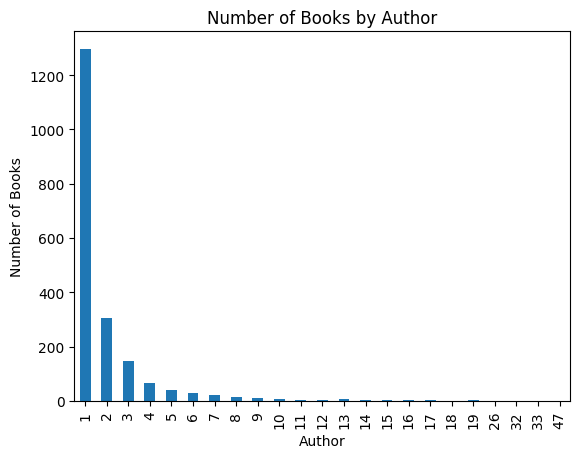

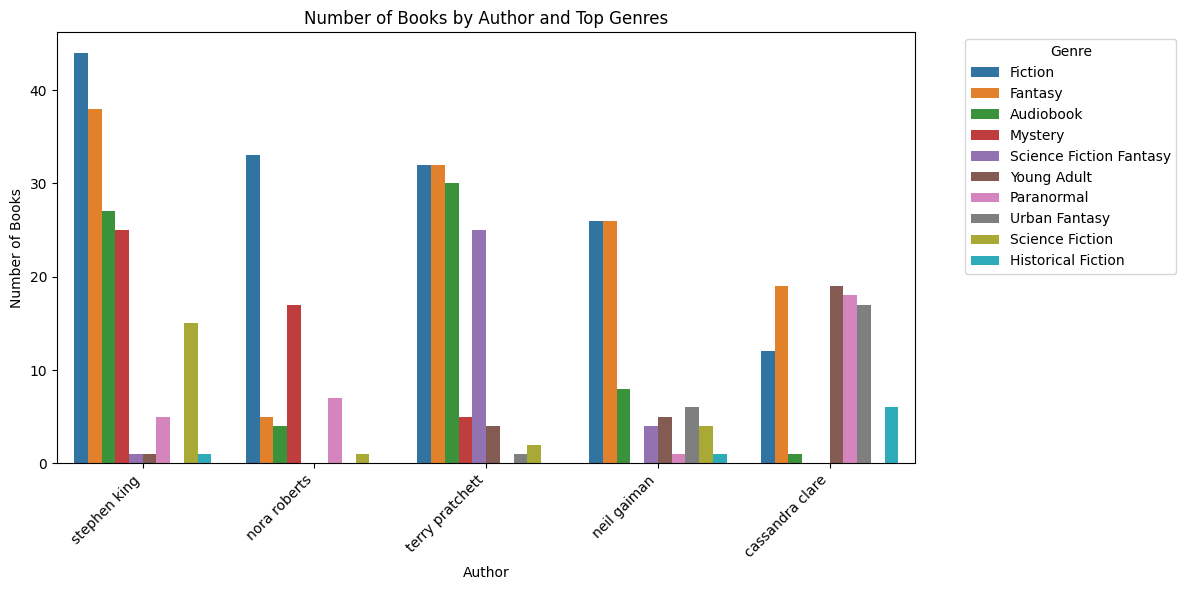

In [ ]:
author_counts = df['authors'].value_counts()
top5_authors = author_counts.head(5)
print(top5_authors)
#bar graph group together authors by number of published books
author_books=author_counts.groupby(author_counts).count()
author_books.plot(kind='bar', title='Number of Books by Author', xlabel='Author', ylabel='Number of Books')
#how many authors write each genre
print(type(df['genres_list'].iloc[0]))
df_exploded = df.explode('genres_list')
author_genre_counts = df_exploded.groupby(['authors', 'genres_list']).size().reset_index(name='book_count')
genreBooks_author=author_genre_counts.sort_values(by='book_count', ascending=False)
print(genreBooks_author.head(10))

genreBooks_author['authors'] = genreBooks_author['authors'].astype(str).str.strip().str.lower()

top5_authors_cleaned = top5_authors.index.str.strip().str.lower()

filtered_genreBooks_author = genreBooks_author[genreBooks_author['authors'].isin(top5_authors_cleaned)]

genre_counts = filtered_genreBooks_author['genres_list'].value_counts()

top_genres = genre_counts.head(10).index

filtered_by_top_genres = filtered_genreBooks_author[filtered_genreBooks_author['genres_list'].isin(top_genres)]

plt.figure(figsize=(12, 6))
sns.barplot(data=filtered_by_top_genres, x='authors', y='book_count', hue='genres_list')
plt.title('Number of Books by Author and Top Genres')
plt.xlabel('Author')
plt.ylabel('Number of Books')
plt.xticks(rotation=45, ha="right")
plt.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#CLEAN UP genre_list, get rid of some genres and group others together




In [ ]:
publi_count = df['publisher'].value_counts()
mean_books_per_publi = publi_count.mean()#keeping 209 so use another metrics
common_publi = publi_count[publi_count >= mean_books_per_publi]
print(common_publi)
top_5_publi=common_publi.head(5)
print(top_5_publi)

publisher
Ballantine Books                 92
Vintage                          80
Berkley                          72
Bantam                           59
St. Martin's Press               55
                                 ..
Bloomsbury                        4
Knopf Books for Young Readers     4
New Directions                    4
MysteriousPress.com/Open Road     4
Piatkus                           4
Name: count, Length: 209, dtype: int64
publisher
Ballantine Books      92
Vintage               80
Berkley               72
Bantam                59
St. Martin's Press    55
Name: count, dtype: int64


<Axes: xlabel='publication_year'>

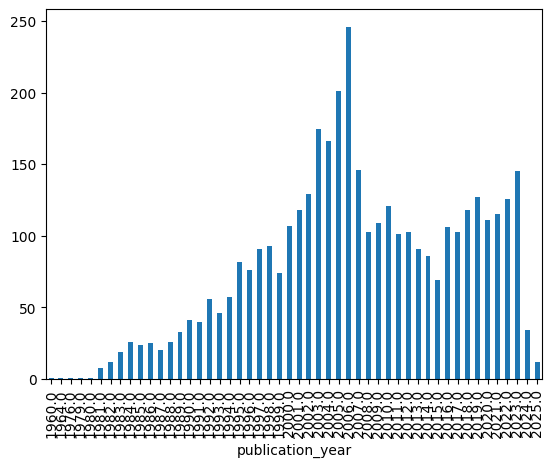

In [ ]:
df['publication_year'].value_counts().sort_index().plot(kind='bar')

<Axes: xlabel='publication_year'>

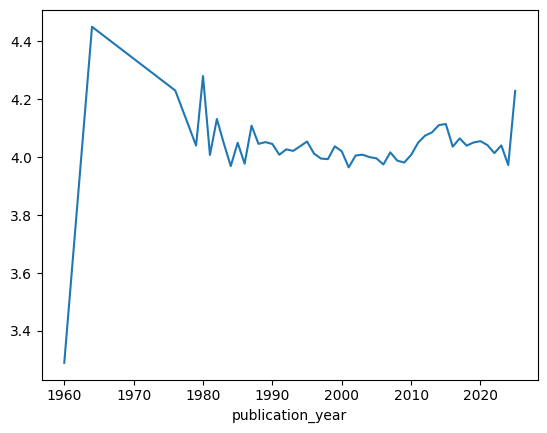

In [ ]:
df.groupby('publication_year')['rating_score'].mean().plot(kind='line')
#based on the graph above it is because no books are published before 1980 so that's why of the big jump
#maybe we should shorten down the range. Would this affect analysis? Should we normalize (the data doesnt seems too skewed for me)?

In [ ]:
#df["genres_list"]=df["genres"].str.split(', ')
#df=df.drop("genres", axis=1)
df.to_csv('/content/drive/MyDrive/final_project/cleaned_book_data.csv', index=False)